# 03 — EDA panel dữ liệu

Luồng B4 — [PHASE-1-CHECKLIST.md §B4](../../PHASE-1-CHECKLIST.md). Chạy được NGAY trên panel v0.1.0 hiện có (mục 1-4 dưới đây không cần khí hậu) — mục 5 (tương quan khí hậu) tự động bỏ qua nếu chưa chạy Luồng A.

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()
if not (_root / "app").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print("project root:", _root)

project root: d:\Cuộc thi\DengueSense\ai-service


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

processed_dirs = sorted((_root / 'data' / 'processed').glob('v*'))
latest_dir = processed_dirs[-1]
panel = pd.read_parquet(latest_dir / 'panel_monthly.parquet')
meta = pd.read_csv(_root / 'data' / 'external' / 'province_metadata.csv', encoding='utf-8')

print('Dùng version:', latest_dir.name)
print('Cột có sẵn:', list(panel.columns))
panel = panel.merge(meta[['new_province_code', 'region']], left_on='province_id', right_on='new_province_code', how='left')
panel.head()

Dùng version: v0.2.0
Cột có sẵn: ['province_id', 'month', 'cases', 'data_source', 'population', 'population_source', 'incidence_per_100k', 'temp_mean', 'precip_total', 'humidity_mean', 'oni']


,province_id,month,cases,data_source,population,population_source,incidence_per_100k,temp_mean,precip_total,humidity_mean,oni,new_province_code,region
0,an_giang,1994-02-01,22.0,real,3467576,imputed,0.634449,27.293281,7.998484,68.056455,0.00,an_giang,Nam
1,an_giang,1994-03-01,64.0,real,3467576,imputed,1.84567,27.896317,79.808851,70.348348,0.04,an_giang,Nam
2,an_giang,1994-04-01,201.0,real,3467576,imputed,5.796556,28.267149,102.635839,75.745204,0.17,an_giang,Nam
3,an_giang,1994-05-01,198.0,real,3467576,imputed,5.710041,27.433387,268.791478,84.858052,0.25,an_giang,Nam
4,an_giang,1994-06-01,499.0,real,3467576,imputed,14.390456,26.897242,246.913222,85.732731,0.23,an_giang,Nam


## 1. Chuỗi ca bệnh theo 3 vùng (Bắc/Trung/Nam)

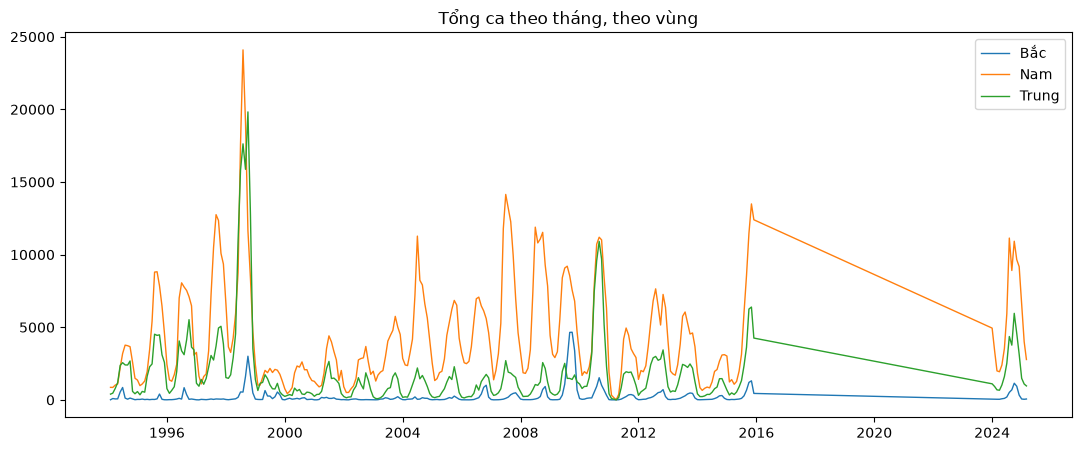

In [3]:
by_region = panel.groupby(['month', 'region'])['cases'].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
for region, g in by_region.groupby('region'):
    ax.plot(g['month'], g['cases'], label=region, linewidth=1)
ax.set_title('Tổng ca theo tháng, theo vùng')
ax.legend()
plt.show()

## 2. Mùa vụ — đỉnh dịch rơi vào tháng nào, có khác giữa vùng không?

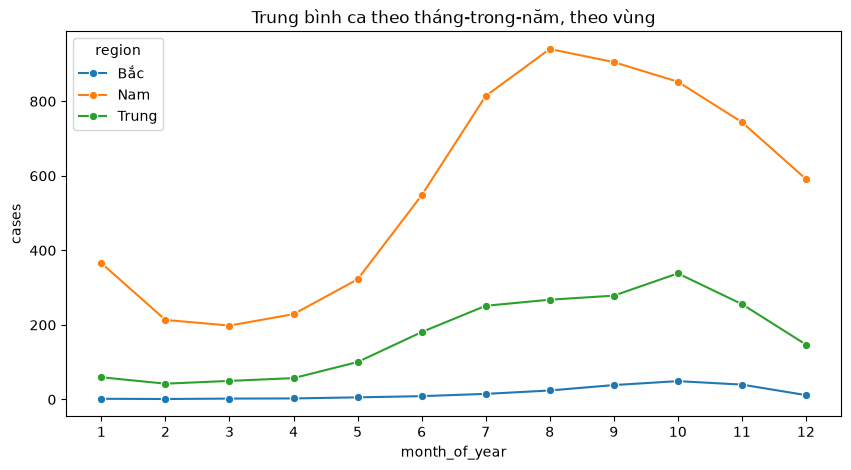

In [4]:
panel['month_of_year'] = panel['month'].dt.month
seasonal = panel.groupby(['region', 'month_of_year'])['cases'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=seasonal, x='month_of_year', y='cases', hue='region', marker='o', ax=ax)
ax.set_xticks(range(1, 13))
ax.set_title('Trung bình ca theo tháng-trong-năm, theo vùng')
plt.show()

## 3. Thống kê khuyết thiếu theo tỉnh × năm

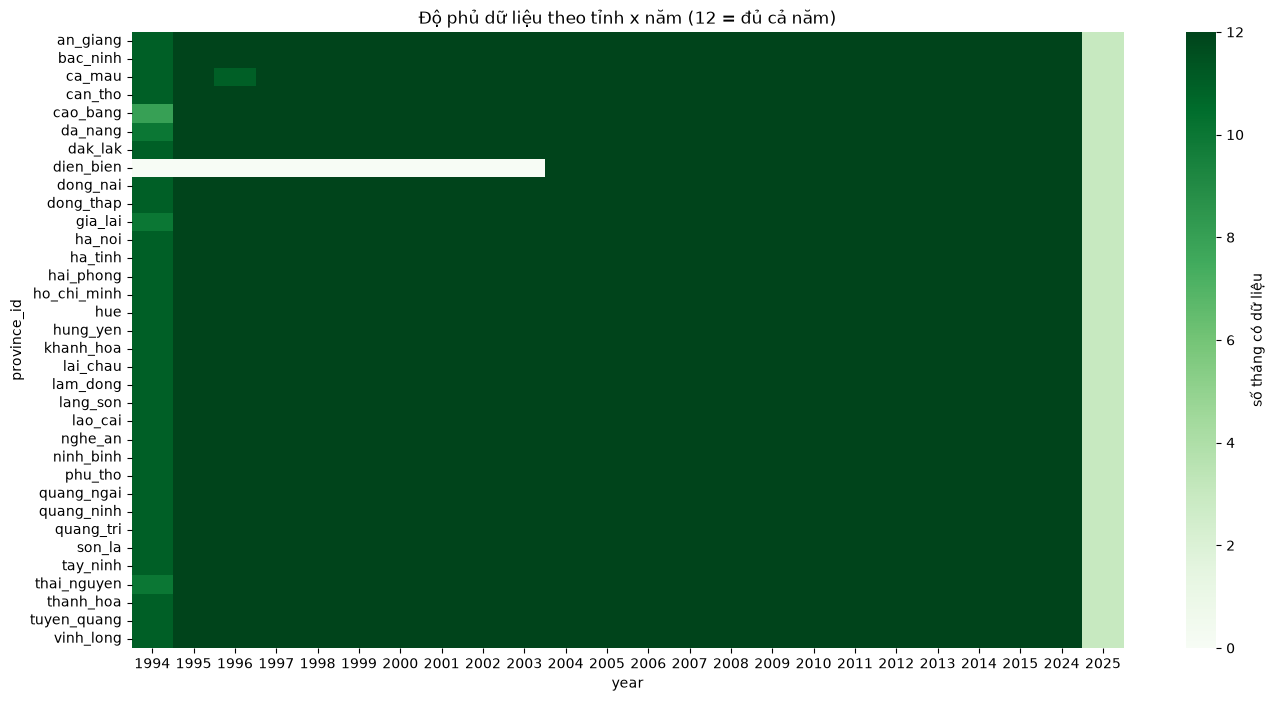

In [5]:
panel['year'] = panel['month'].dt.year
coverage = panel.groupby(['province_id', 'year']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(coverage, cmap='Greens', cbar_kws={'label': 'số tháng có dữ liệu'}, ax=ax)
ax.set_title('Độ phủ dữ liệu theo tỉnh x năm (12 = đủ cả năm)')
plt.show()

## 4. So sánh phân phối `real` vs `estimated` — ước lượng có lệch hệ thống không?

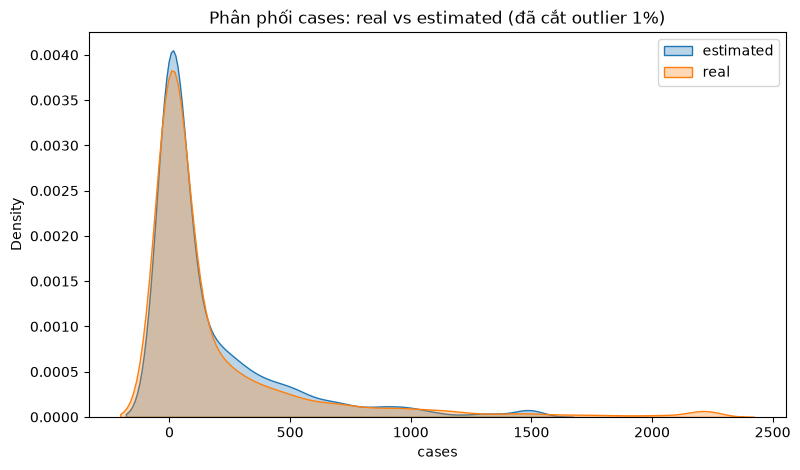

,count,mean,std,min,25%,50%,75%,max
data_source,,,,,,,,
estimated,2550.0,173.194902,315.595496,0.0,0.375302,19.686995,222.754895,2979.515398
real,6776.0,203.586629,470.397350,0.0,0.000000,10.000000,197.000000,8539.000000


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for source, g in panel.groupby('data_source'):
    sns.kdeplot(g['cases'].clip(upper=g['cases'].quantile(0.99)), label=source, ax=ax, fill=True, alpha=0.3)
ax.set_title('Phân phối cases: real vs estimated (đã cắt outlier 1%)')
ax.legend()
plt.show()

panel.groupby('data_source')['cases'].describe()

## 5. Tương quan chéo khí hậu ↔ ca bệnh theo độ trễ (chỉ chạy được sau Luồng A)

⚠️ Đừng giả định "1-3 tháng là mạnh nhất" — đo rồi mới kết luận, con số này quyết định thiết kế đặc trưng ở Phase 2.

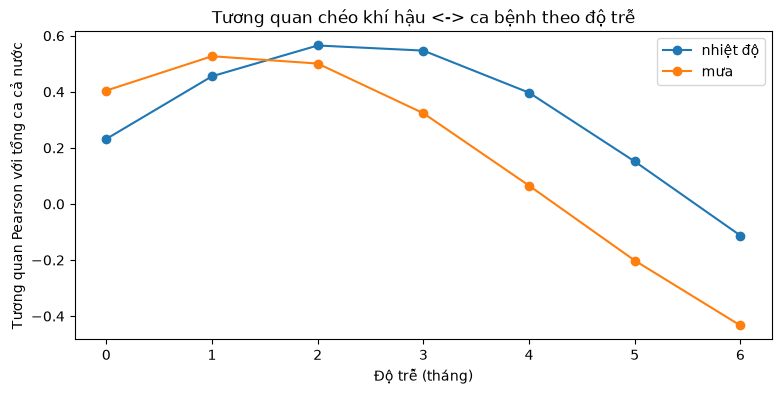

In [7]:
if 'temp_mean' not in panel.columns:
    print('Chưa có cột khí hậu — chạy notebooks/02_ingest_era5.ipynb rồi build lại panel trước khi chạy phần này.')
else:
    monthly = panel.groupby('month').agg(cases=('cases', 'sum'), temp_mean=('temp_mean', 'mean'),
                                          precip_total=('precip_total', 'mean')).sort_index()
    lags = range(7)
    corr_temp = [monthly['cases'].corr(monthly['temp_mean'].shift(lag)) for lag in lags]
    corr_precip = [monthly['cases'].corr(monthly['precip_total'].shift(lag)) for lag in lags]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(list(lags), corr_temp, marker='o', label='nhiệt độ')
    ax.plot(list(lags), corr_precip, marker='o', label='mưa')
    ax.set_xlabel('Độ trễ (tháng)')
    ax.set_ylabel('Tương quan Pearson với tổng ca cả nước')
    ax.legend()
    ax.set_title('Tương quan chéo khí hậu <-> ca bệnh theo độ trễ')
    plt.show()

## Việc cần Minh Dương rà soát

Nhìn dưới góc độ y sinh: có gì vô lý về mặt dịch tễ trong các biểu đồ trên không (mùa vụ sai logic, vùng bất thường, đỉnh dịch lệch năm không giải thích được)?